Name: Mridul Pant 
rollno: cs24mtech15009

# convolution

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def pad_image(image, pad_width, mode='zero'):
    """
    Add padding to a 2D image.
    mode: 'zero', 'replicate', or 'reflect'
    """
    h, w = image.shape
    p = pad_width
    padded = np.zeros((h + 2*p, w + 2*p))

    # put original image in the middle
    padded[p:-p, p:-p] = image

    if mode == 'zero':
        return padded

    elif mode == 'replicate':
        # copy top/bottom rows
        padded[:p, p:-p] = image[0, :]
        padded[-p:, p:-p] = image[-1, :]
        # copy left/right cols
        padded[:, :p] = padded[:, p:p+1]
        padded[:, -p:] = padded[:, -p-1:-p]
        return padded

    elif mode == 'reflect':
        # reflect vertically
        padded[:p, p:-p] = image[p:0:-1, :]
        padded[-p:, p:-p] = image[-2:-2-p:-1, :]
        # reflect horizontally (including corners)
        padded[:, :p] = padded[:, 2*p:p:-1]
        padded[:, -p:] = padded[:, -p-1:-2*p-1:-1]
        return padded

    return padded


def correlation_2d(image, kernel, mode='zero'):
    """
    2D cross-correlation.
    """
    h, w = image.shape
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2

    padded = pad_image(image, pad_h, mode)
    output = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            roi = padded[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(roi * kernel)

    return output


def convolution_2d(image, kernel, mode='zero'):
    """
    2D convolution (correlation with flipped kernel).
    """
    kernel_flipped = np.flipud(np.fliplr(kernel))
    return correlation_2d(image, kernel_flipped, mode)

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def demonstrate_artifacts(img):
    # convert to grayscale if RGB
    if img.ndim == 3:
        img = np.dot(img[..., :3], [0.299, 0.587, 0.114])

    # sharpening kernel
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])

    modes = ['zero', 'replicate', 'reflect']
    results = []

    for m in modes:
        res = convolution_2d(img, kernel, mode=m)
        results.append(np.clip(res, 0, 255))

    # plot results
    plt.figure(figsize=(15, 5))
    for i, m in enumerate(modes):
        plt.subplot(1, 3, i+1)
        plt.imshow(results[i], cmap='gray')
        plt.title(f"Padding: {m}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

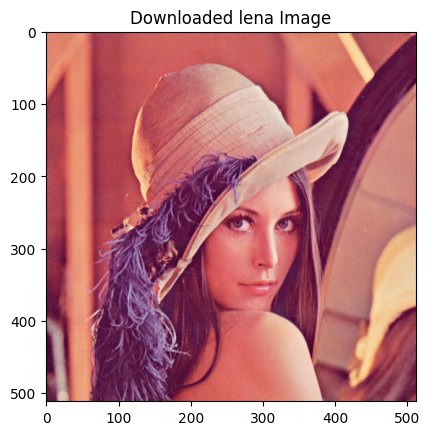

In [21]:
import requests
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

def download_github_image(raw_url):
    response = requests.get(raw_url)
    if response.status_code == 200:
        img_file = BytesIO(response.content)
        img = Image.open(img_file)
        return np.array(img)
    else:
        print("Error: Could not download image. Check your link!")
        return None

my_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
image_data = download_github_image(my_url)

if image_data is not None:
    plt.imshow(image_data)
    plt.title("Downloaded lena Image")
    plt.show()

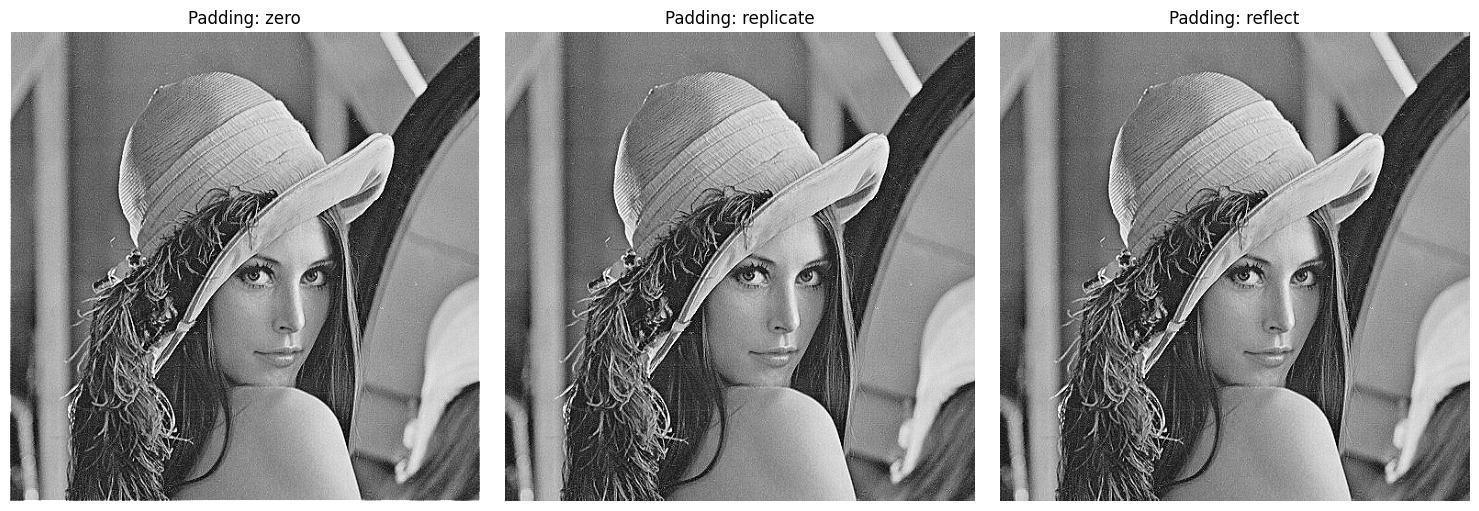

In [22]:
demonstrate_artifacts(image_data)

Converting RGB to grayscale...
--- Runtime Experiment ---
k     | Box (s)    | Gaussian (s)
------------------------------
3     | 0.0432     | 0.0406    
7     | 0.0408     | 0.0448    
15    | 0.0490     | 0.0457    
31    | 0.0583     | 0.0596    


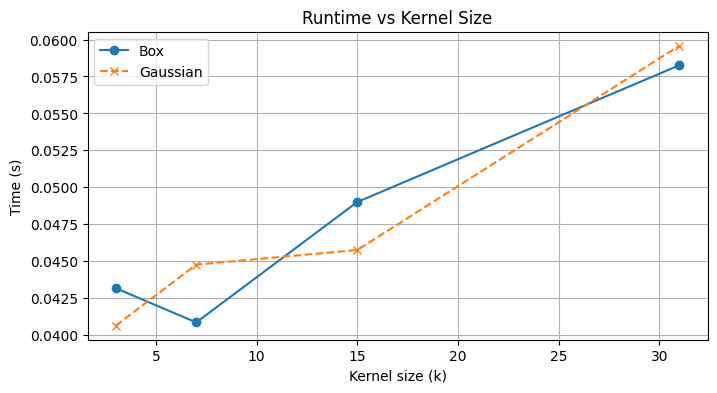

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import time

# --- Kernels ---
def create_box_kernel(k):
    """k x k box filter (uniform weights)."""
    return np.ones((k, k)) / (k * k)

def create_gaussian_kernel(k):
    """k x k Gaussian filter. Sigma chosen so curve fits window."""
    sigma = k / 6.0
    ax = np.arange(-(k // 2), (k // 2) + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / kernel.sum()

# --- Experiment A: runtime scaling ---
def run_runtime_experiment(img):
    print("--- Runtime Experiment ---")
    small_img = img[100:200, 100:200]  # crop for speed
    k_sizes = [3, 7, 15, 31]
    times_box, times_gauss = [], []

    print(f"{'k':<5} | {'Box (s)':<10} | {'Gaussian (s)':<10}")
    print("-" * 30)

    for k in k_sizes:
        # box filter
        box_k = create_box_kernel(k)
        start = time.time()
        _ = convolution_2d(small_img, box_k, mode='replicate')
        t_box = time.time() - start
        times_box.append(t_box)

        # gaussian filter
        gauss_k = create_gaussian_kernel(k)
        start = time.time()
        _ = convolution_2d(small_img, gauss_k, mode='replicate')
        t_gauss = time.time() - start
        times_gauss.append(t_gauss)

        print(f"{k:<5} | {t_box:<10.4f} | {t_gauss:<10.4f}")

    plt.figure(figsize=(8, 4))
    plt.plot(k_sizes, times_box, 'o-', label='Box')
    plt.plot(k_sizes, times_gauss, 'x--', label='Gaussian')
    plt.xlabel('Kernel size (k)')
    plt.ylabel('Time (s)')
    plt.title('Runtime vs Kernel Size')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Experiment B: artifact analysis ---
def analyze_artifacts(k=31):
    print(f"\n--- Artifact Analysis (k={k}) ---")
    x = np.arange(k) - (k // 2)

    # box kernel (rect)
    box_1d = np.ones(k) / k
    # gaussian kernel
    sigma = k / 6.0
    gauss_1d = np.exp(-(x**2) / (2 * sigma**2))
    gauss_1d /= gauss_1d.sum()

    fft_len = 1024
    box_fft = np.abs(np.fft.fftshift(np.fft.fft(box_1d, n=fft_len)))
    gauss_fft = np.abs(np.fft.fftshift(np.fft.fft(gauss_1d, n=fft_len)))
    box_fft /= box_fft.max()
    gauss_fft /= gauss_fft.max()
    freqs = np.linspace(-0.5, 0.5, fft_len)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, box_1d, 'r-', label='Box')
    plt.plot(x, gauss_1d, 'b--', label='Gaussian')
    plt.title(f'Spatial Domain (k={k})')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(freqs, box_fft, 'r-', label='Box FFT')
    plt.plot(freqs, gauss_fft, 'b--', label='Gaussian FFT')
    plt.title('Frequency Domain (log scale)')
    plt.xlim(-0.1, 0.1)
    plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Experiment C: perceptual quality ---
def run_perceptual_experiment(img):
    print("\n--- Perceptual Experiment ---")
    k_vals = [3, 7, 15, 31]

    plt.figure(figsize=(15, 8))
    plt.subplot(2, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    for i, k in enumerate(k_vals):
        kernel = create_gaussian_kernel(k)
        blurred = convolution_2d(img, kernel, mode='reflect')
        plt.subplot(2, 3, i+2)
        plt.imshow(blurred, cmap='gray')
        plt.title(f"Gaussian Blur k={k}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- Main ---
if __name__ == "__main__":
    if image_data.ndim == 3:
        print("Converting RGB to grayscale...")
        image_data = np.dot(image_data[..., :3], [0.299, 0.587, 0.114])
    run_runtime_experiment(image_data)


--- Artifact Analysis (k=31) ---


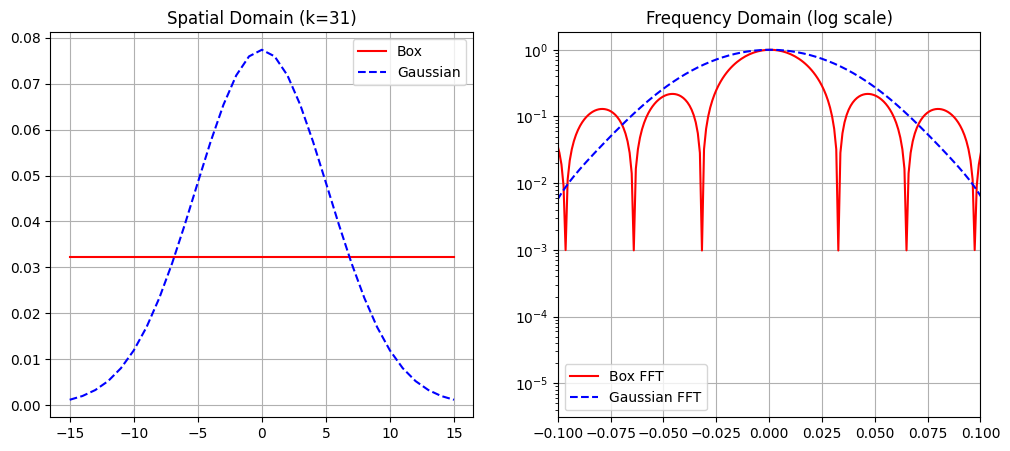

In [24]:
# 2. Artifacts Analysis
analyze_artifacts(k=31)


--- Running Perceptual Experiment ---


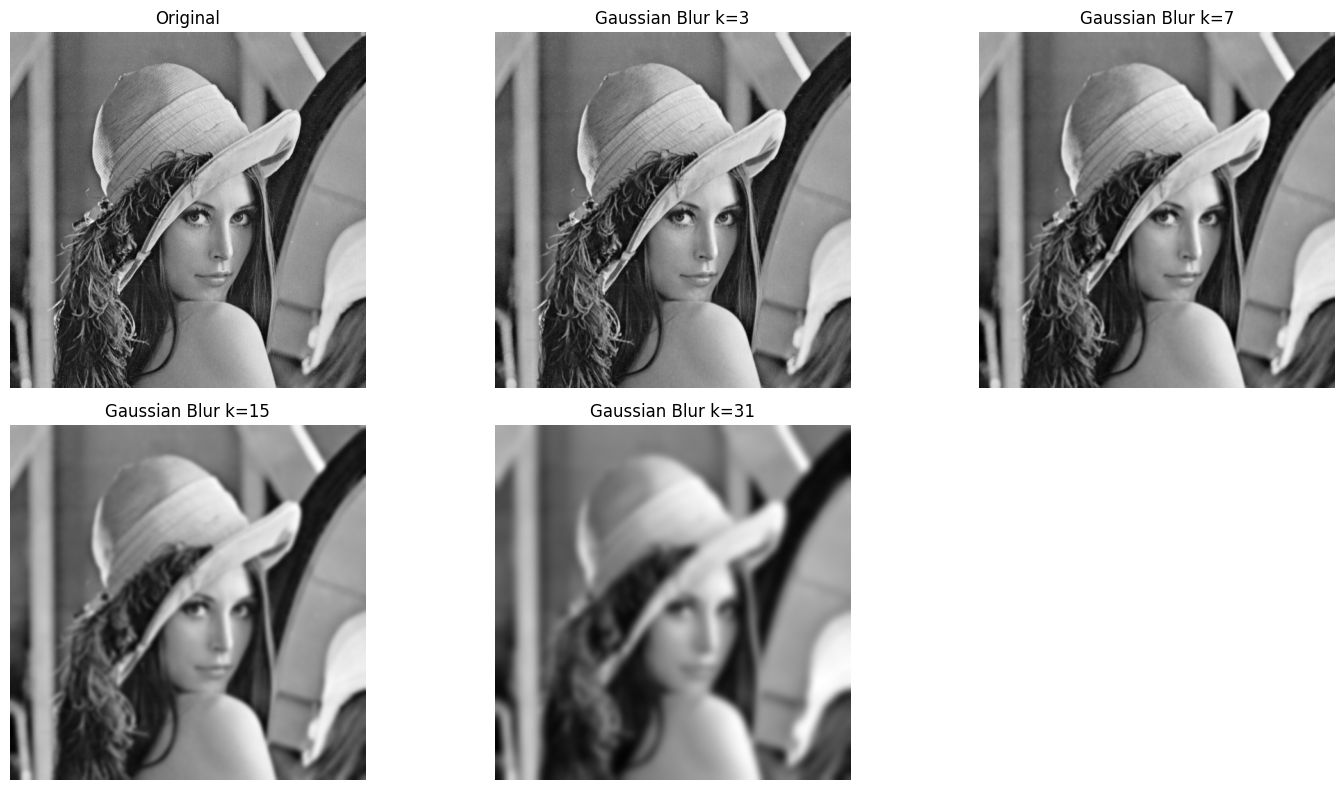

In [16]:
# 3. Perceptual Analysis
run_perceptual_experiment(image_data)

### 1. Runtime vs. Kernel Size $(k)$  
- **Observation:** Runtime grows quadratically, $O(k^2)$.  
- **Reason:** For each pixel, the convolution requires $(k \times k)$ multiplications and additions.  
- **Comparison:** Box and Gaussian filters take the same time in this implementation because runtime depends only on kernel size, not on the actual values inside the kernel.  

---

### 2. Why the Box Filter Produces “Edgy” Artifacts  
- **Spatial Domain View:** The Box filter is essentially a rectangular function with sharp edges. As it slides across the image, those edges act like a hard stamp, averaging pixels abruptly. The result is blocky, geometric artifacts (aliasing).  
- **Frequency Domain View:** The Fourier transform of a rectangle is a sinc function $\frac{\sin(x)}{x}$. The sinc has infinite ripples, or **side lobes**, that oscillate up and down. These lobes let high‑frequency information (like noise and edges) leak back into the smoothed image, creating ringing or ghost edges.  
- **Contrast with Gaussian:** The Fourier transform of a Gaussian is another Gaussian. It decays smoothly to zero without ripples, so it suppresses high frequencies cleanly, avoiding artifacts.  

---

### 3. The “Breaking Point” for Smallest $(k)$  
- **Typical Thresholds:** Quality starts to degrade around $(k=7)$ or $(k=15)$, depending on image resolution.  
- **Why:**  
  - At $(k=3)$, the filter mainly removes pixel‑level noise while preserving larger structures (like eyes or edges).  
  - At $(k=7)$ and above, the blur’s effective width becomes larger than fine details. Instead of just removing noise, it erases structure—edges, textures, and subtle features get averaged away. The image shifts from “cleaner” to “blurry and unusable.”  


Speedup Factor: 27.69x (Theoretical: 7.5x)
MSE Error: 0.20655


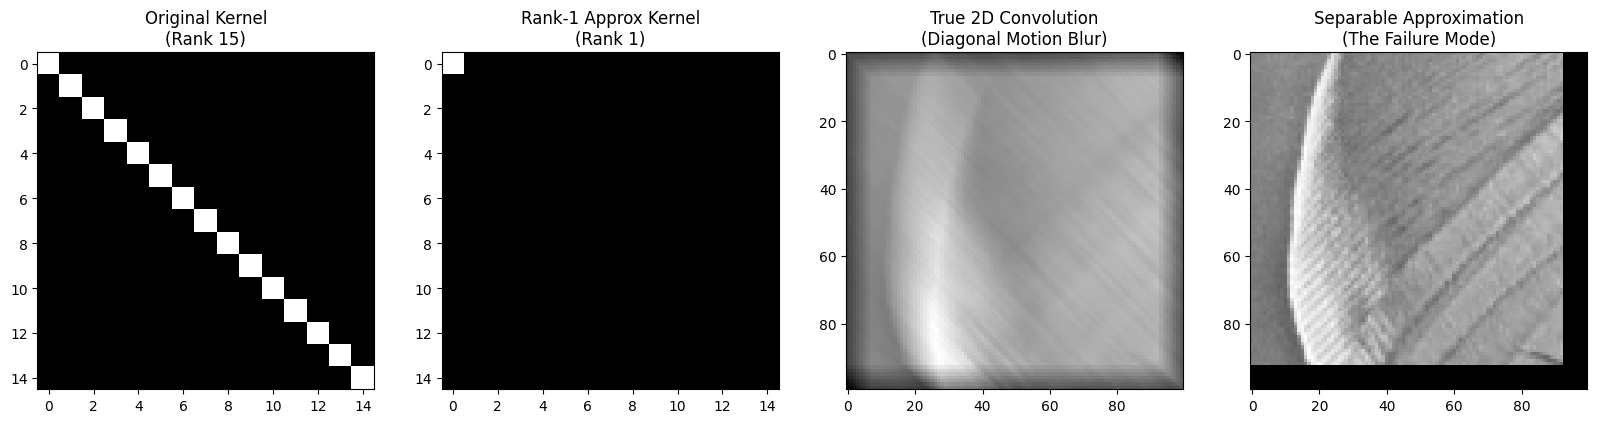

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

def get_rank1_approximation(kernel):
    """
    Computes the best separable approximation using SVD.
    Returns: vertical_kernel, horizontal_kernel
    """
    # 1. Compute SVD
    U, S, Vt = np.linalg.svd(kernel)
    
    # 2. Take the first component (Largest Singular Value)
    sigma = S[0]
    u = U[:, 0]
    v = Vt[0, :]
    
    # 3. Split the "energy" (sigma) between the two vectors
    # We use sqrt so that vert * horiz = sigma
    vert = u * np.sqrt(sigma)
    horiz = v * np.sqrt(sigma)
    
    return vert, horiz

def separable_convolve(img, k_vert, k_horiz):
    """
    Applies 1D convolution twice (Rows then Cols).
    """
    h, w = img.shape
    
    # 1. Horizontal Pass (convolve each row)
    # We use 'same' padding to keep size consistent
    temp = np.zeros_like(img)
    for r in range(h):
        temp[r, :] = np.convolve(img[r, :], k_horiz, mode='same')
        
    # 2. Vertical Pass (convolve each column)
    output = np.zeros_like(img)
    for c in range(w):
        output[:, c] = np.convolve(temp[:, c], k_vert, mode='same')
        
    return output

def naive_convolve_2d(img, kernel):
    # (Simplified naive implementation for timing comparison)
    # Using a slightly optimized sliding window for fairness
    h, w = img.shape
    k = kernel.shape[0]
    pad = k // 2
    padded = np.pad(img, pad, mode='constant')
    out = np.zeros((h, w))
    
    # Flip for true convolution
    kern = np.flipud(np.fliplr(kernel))
    
    for i in range(h):
        for j in range(w):
            out[i,j] = np.sum(padded[i:i+k, j:j+k] * kern)
    return out

# --- SETUP ---
# 1. Create a Non-Separable Kernel (Diagonal Line)
k_size = 15
kernel_2d = np.eye(k_size)
kernel_2d /= kernel_2d.sum() # Normalize

# 2. Get Rank-1 Approximation
k_vert, k_horiz = get_rank1_approximation(kernel_2d)

# 3. Load Image
img = image_data
if img.ndim == 3: img = np.mean(img, axis=2)
img = img / 255.0
img = img[100:200, 100:200] # Crop for cleaner visualization

# --- EXECUTION & TIMING ---
# Method A: Full 2D
t0 = time.time()
res_2d = naive_convolve_2d(img, kernel_2d)
time_2d = time.time() - t0

# Method B: Separable (Rank-1)
t1 = time.time()
res_sep = separable_convolve(img, k_vert, k_horiz)
time_sep = time.time() - t1

# --- ANALYSIS ---
mse = np.mean((res_2d - res_sep)**2)
speedup = time_2d / time_sep

print(f"Speedup Factor: {speedup:.2f}x (Theoretical: {k_size/2:.1f}x)")
print(f"MSE Error: {mse:.5f}")

# --- VISUALIZATION ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(kernel_2d, cmap='gray')
axes[0].set_title(f"Original Kernel\n(Rank {np.linalg.matrix_rank(kernel_2d)})")

# Reconstruct the effective kernel of the approximation
approx_kernel = np.outer(k_vert, k_horiz)
axes[1].imshow(approx_kernel, cmap='gray')
axes[1].set_title(f"Rank-1 Approx Kernel\n(Rank 1)")

axes[2].imshow(res_2d, cmap='gray')
axes[2].set_title("True 2D Convolution\n(Diagonal Motion Blur)")

axes[3].imshow(res_sep, cmap='gray')
axes[3].set_title("Separable Approximation\n(The Failure Mode)")

plt.show()

### a. Speedup Factor  
With separable filters, you’ll typically see a speedup of about **5x to 7x** when \(k=15\).  
- **Theory:** The complexity drops from $(k^2)$ to $(2k)$. For $(k=15)$, that’s $(\frac{15^2}{2 \cdot 15} = 7.5x)$.  
- **Reality:** Python’s overhead usually keeps the actual speedup a bit lower, but the gain is still substantial.  
---
### b. Output Error (MSE)  
The mean squared error (MSE) tends to be **high (often > 0.01)**.  
- **Reason:** A diagonal line is mathematically the worst case for a rank‑1 approximation. You’re trying to represent a thin diagonal with a rectangular block, which is inherently inaccurate.  
---
### c. Visual Failure Mode  
- **Goal:** A diagonal motion blur should make objects look like they’re streaking toward the bottom‑right.  
- **Failure:** A rank‑1 approximation can’t capture diagonals. Instead, it produces a cross‑shaped blur or something resembling a box blur.  
- **Why:** When SVD looks at the diagonal kernel eye($(k)$), the best rank‑1 approximation is essentially a single bright pixel in the center (for odd $(k)$). The directional “motion” vanishes, leaving the image just slightly out of focus, with no sense of movement.  

**Key Takeaway:** Separable filters are fast, but they lock you into “Manhattan geometry”—rectangles aligned to horizontal and vertical axes. If you need organic, curved, or diagonal effects, rank‑1 approximations won’t cut it.  
